Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


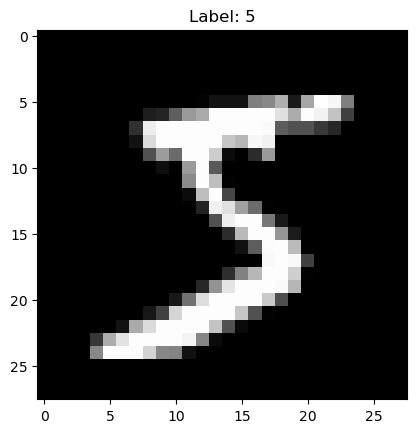

F:\anacondaa\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8696 - loss: 0.4487 - val_accuracy: 0.9597 - val_loss: 0.1328
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9655 - loss: 0.1126 - val_accuracy: 0.9707 - val_loss: 0.0977
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9772 - loss: 0.0746 - val_accuracy: 0.9693 - val_loss: 0.0981
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9828 - loss: 0.0531 - val_accuracy: 0.9733 - val_loss: 0.0954
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9875 - loss: 0.0407 - val_accuracy: 0.9716 - val_loss: 0.0991
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.1155

Test Accuracy: 0.9703999757766724
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


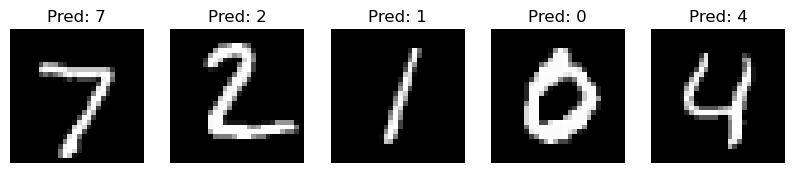

Model Saved Successfully!


In [1]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display Dataset Shape
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

# Normalize Data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Display One Image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Build Neural Network Model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# Predict on Test Images
predictions = model.predict(x_test)

# Display Prediction
plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(x_test[i], cmap='gray')

    predicted_label = np.argmax(predictions[i])

    plt.title(f"Pred: {predicted_label}")

    plt.axis('off')

plt.show()

# Save Model
model.save("mnist_model.h5")

print("Model Saved Successfully!")